# 흉부 X-ray 폐렴 분류 — v8 (폐 영역만 잘라서 학습 + 다중 TTA)

지금까지 모델은 X-ray **전체**를 봤습니다. 그런데 사진에는 팔, 배, 'R' 표시, 튜브, 글자처럼 **폐렴과 상관없는 부분**도 많습니다.
모델이 이런 부분을 단서로 외우면, 다른 병원·다른 시기에 찍은 test에서 틀리기 쉽습니다(train/test 분포 차이).

| 바꾼 점 | 내용 |
|---|---|
| **B. 폐 영역 자르기** | X-ray 전용 폐 분할 모델(`torchxrayvision`의 PSPNet)로 양쪽 폐 위치를 찾고, 그 상자(+여백 8%)만 잘라 224×224로 키워서 학습·예측 |
| **A. 다중 TTA** | 예측할 때 원본·좌우반전에 더해 **1.1배 확대, 0.9배 축소** 버전까지 4가지 확률을 평균 |
| 앙상블 | v4(EfficientNet 전체 사진) + v5(X-ray DenseNet 전체 사진) + **v8(EfficientNet 폐만)** 순위 평균 |

나머지(5-fold 환자 묶음 분할, 클래스 가중치, 증강, 6 에포크, 옵티마이저)는 v4와 같습니다.

**폐 분할은 사진 한 장씩 따로** 하므로 test의 통계를 쓰지 않습니다 (letterbox와 같은 종류의 전처리). test는 예측에만 사용합니다.
예상 시간: 폐 위치 찾기 약 70분(처음 한 번만, 이후엔 저장된 `lung_boxes.csv` 사용) + 학습 약 1시간 30분. 결과: `lung_boxes.csv`, `test_prob_v8.npy`, `submission_rank_v4_v5_v8_r58.csv`

## 라이브러리 설치 (처음 한 번만)
v5에서 이미 설치했다면 건너뛰어도 됩니다.

In [1]:
%pip install torchxrayvision

Note: you may need to restart the kernel to use updated packages.


## 0. 데이터 준비 (VS Code / 로컬)
데이터 폴더(`train/`, `test/`, `train.csv`, `test.csv`, `sample_submission.csv`)가 있는 경로를 `DATA_DIR`에 적어 주세요.
맥(M1/M2)에서는 GPU 역할을 하는 **mps**가 자동으로 사용됩니다.

VS Code에서 처음 실행할 때 오른쪽 위 **커널 선택**에서 torch가 설치된 파이썬을 고르세요. 라이브러리가 없다면 아래 명령을 터미널에서 한 번 실행합니다.
`pip install torch torchvision scikit-learn pandas matplotlib pillow`

In [2]:
import os

DATA_DIR = "."   # 데이터가 들어 있는 폴더 경로 (본인 경로에 맞게 수정)
os.chdir(DATA_DIR)                                 # 작업 폴더를 데이터 폴더로 이동 → 이후 "train.csv"처럼 짧은 경로 사용 가능

print(os.getcwd())                                 # 현재 작업 폴더 확인
print(os.listdir())                                # train, test, train.csv, test.csv, sample_submission.csv 가 보여야 정상
print("train 이미지 수:", len(os.listdir("train")))   # 5216
print("test 이미지 수:", len(os.listdir("test")))     # 624

.
['model_xrv_chex.pt', 'best_model_fold1.pt', 'test_prob_xrv_chex.npy', 'submission_v5_r58.csv', 'best_model_v7_fold3.pt', 'test_probs_v4_folds.npy', 'xray_v8_lungcrop.ipynb', 'submission_v2.csv', 'best_model_v8_fold1.pt', 'best_model_fold5.pt', 'xray_v6_xrv_multi.ipynb', 'submission_v3.csv', 'xray_v5_xrv.ipynb', 'best_model_fold4.pt', '.DS_Store', 'test_prob_xrv_pc.npy', 'test', 'best_model_v7_fold2.pt', 'submission_rank_v4_v5_r58.csv', 'test_prob_v3.npy', 'best_model_v5_fold4.pt', 'test_probs_v5_folds.npy', 'submission_v4_t05.csv', 'test_prob_v2.npy', 'submission_v4_t099.csv', 'submission_v5_t099.csv', 'test.csv', 'test_probs_v8_folds.npy', 'test_prob_v1.npy', 'submission.csv', 'submission_v7_r58.csv', 'test_prob_v5.npy', 'best_model_v5_fold1.pt', 'test_prob_v4.npy', 'best_model_v5_fold5.pt', 'test_prob_v7.npy', 'submission_v5_t05.csv', 'submission_ens_v1_v3_r66.csv', 'best_model_v3.pt', 'best_model_v5_fold2.pt', 'model_xrv_pc.pt', 'xray_v7_convnext.ipynb', 'submission_ens_v1_v2_r62

## 1. 라이브러리 불러오기
baseline과 같고, 사전학습 모델을 쓰기 위해 `torchvision.models`, 환자 묶음 단위로 5조각을 나누기 위해 `StratifiedGroupKFold`, 결과 확인용 `accuracy_score`, `confusion_matrix`를 추가했습니다.

In [3]:
import os, random                      # os: 파일 경로 다루기 / random: 파이썬 난수
import numpy as np, pandas as pd       # numpy: 숫자 배열 계산 / pandas: CSV 표 다루기
from PIL import Image                  # 이미지 파일 열기·자르기·붙이기

import torch                                        # PyTorch 핵심
import torch.nn.functional as F                     # 확대·축소(interpolate) 등 텐서 함수
import torchxrayvision as xrv                       # 폐 분할 모델(PSPNet)
import torch.nn as nn                               # 신경망 층(Linear 등)과 손실함수
import torch.optim as optim                         # 옵티마이저(AdamW)와 학습률 스케줄러
from torch.utils.data import Dataset, DataLoader    # 데이터를 모델에 배치 단위로 넣어주는 도구
from torchvision import transforms, models          # transforms: 이미지 전처리·증강 / models: 사전학습 모델 모음

from sklearn.model_selection import StratifiedGroupKFold      # 묶음(group) 단위 + 정상/폐렴 비율 유지하며 k조각으로 나누기
from sklearn.metrics import accuracy_score, confusion_matrix  # 정확도(대회 평가 산식), 혼동행렬

# 실행할 때마다 결과가 같도록 시드 고정
random.seed(42); np.random.seed(42); torch.manual_seed(42)   # 파이썬·numpy·torch 난수를 모두 42로 고정

# GPU가 있으면 GPU(cuda), 맥이면 mps, 없으면 cpu
if torch.cuda.is_available():                 # 코랩 GPU(T4 등)가 있으면
    device = torch.device("cuda")
elif torch.backends.mps.is_available():       # 맥(M1/M2) GPU가 있으면
    device = torch.device("mps")
else:                                         # 둘 다 없으면 CPU (매우 느림)
    device = torch.device("cpu")
print(device)                                 # 코랩에서는 'cuda'가 나와야 정상

/opt/miniconda3/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


mps


## 2. 이미지 전처리

**letterbox**: 이미지를 가로세로 비율을 유지한 채 224 안에 들어가게 줄이고, 남는 부분을 검은색으로 채웁니다. train과 똑같은 모양을 만들기 위해 test(와 검증)에 사용합니다. train 이미지는 이미 224×224라서 이 함수를 거쳐도 그대로입니다.

사전학습 모델은 컬러(3채널) 사진으로 학습됐기 때문에 `Grayscale(3)`으로 흑백 한 장을 3채널로 복사하고, ImageNet 평균/표준편차로 정규화합니다.

In [4]:
IMG_SIZE = 224    # 모델에 넣을 이미지 크기 (train 이미지 크기와 같게)

def letterbox(img):
    img = img.copy()                                  # 원본을 건드리지 않도록 복사
    img.thumbnail((IMG_SIZE, IMG_SIZE))              # 비율 유지하며 긴 변을 224로 줄이기 (예: 1600×1000 → 224×140)
    canvas = Image.new("L", (IMG_SIZE, IMG_SIZE), 0)  # 224×224 검은 도화지 ("L"=흑백, 0=검정)
    x = (IMG_SIZE - img.size[0]) // 2                 # 가로 여백의 절반 → 왼쪽 시작 위치
    y = (IMG_SIZE - img.size[1]) // 2                 # 세로 여백의 절반 → 위쪽 시작 위치 (예: (224-140)//2 = 42)
    canvas.paste(img, (x, y))                          # 가운데에 붙이기 → 위아래(또는 좌우)가 검은 띠
    return canvas

# 학습용: 매번 조금씩 다르게 변형(증강)
train_tf = transforms.Compose([
    transforms.RandomAffine(degrees=10, translate=(0.05, 0.05), scale=(0.9, 1.1)),  # ±10도 회전, 상하좌우 5% 이동, 0.9~1.1배 확대/축소
    transforms.ColorJitter(brightness=0.2, contrast=0.2),                           # 밝기·대비를 ±20% 범위에서 무작위로 변경
    transforms.Grayscale(3),                                                        # 흑백 1채널 → 같은 값 3채널 (사전학습 모델은 RGB 입력)
    transforms.ToTensor(),                                                          # PIL 이미지 → 텐서, 픽셀 0~255 → 0~1
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),             # ImageNet 평균/표준편차로 정규화 (사전학습 때와 같은 기준)
])

# 검증/테스트용: 변형 없이
eval_tf = transforms.Compose([
    transforms.Grayscale(3),                                                # 학습 때와 똑같이 3채널로
    transforms.ToTensor(),                                                  # 텐서 변환
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),     # 같은 정규화 (증강은 하지 않음 → 매번 같은 결과)
])

## 3. 폐 위치 찾기 (처음 한 번만, 약 70분)
흉부 X-ray 전용 분할 모델(PSPNet)이 사진마다 **왼쪽 폐, 오른쪽 폐** 영역을 픽셀 단위로 표시해 줍니다.
두 폐를 모두 감싸는 사각형(상자)을 구해서 `lung_boxes.csv`에 저장합니다. 파일이 이미 있으면 다시 계산하지 않습니다.
- 분할 모델은 512×512, 픽셀 값 -1024~1024 입력을 받습니다.
- 폐를 못 찾았거나 상자가 너무 작으면(사진의 20% 미만) 잘라내지 않고 사진 전체를 씁니다.

상자 크기 비율 (train/test 비교용):
         count   mean    std    min    25%    50%    75%    max
folder                                                         
test     624.0  0.431  0.096  0.191  0.364  0.425  0.495  0.727
train   5216.0  0.417  0.098  0.000  0.351  0.414  0.483  1.000


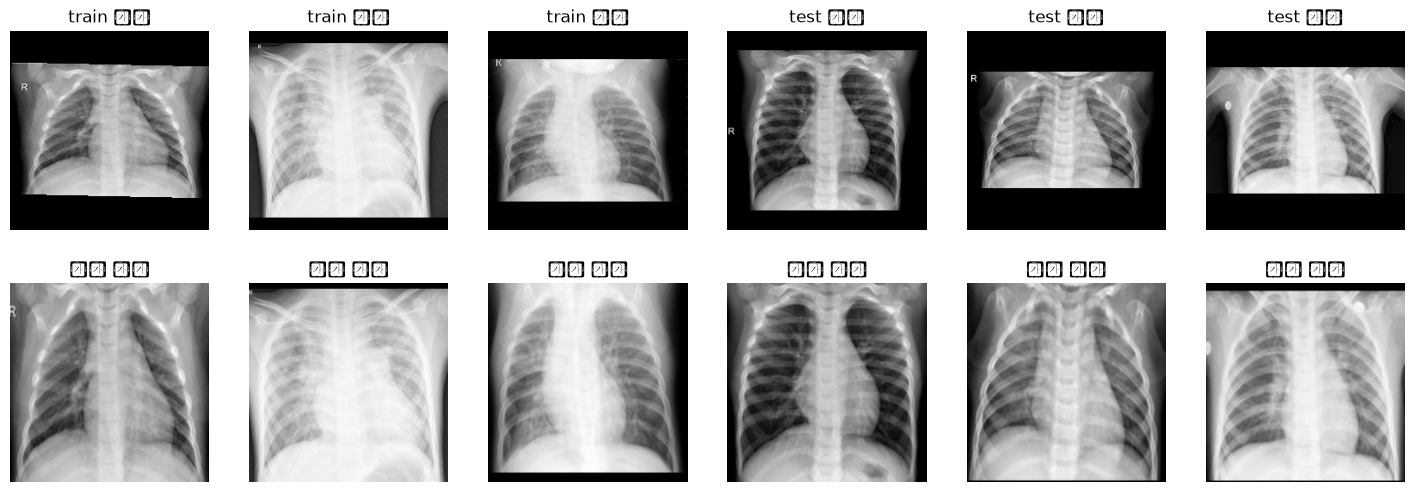

In [5]:
BOX_FILE = "lung_boxes.csv"

if not os.path.exists(BOX_FILE):
    seg = xrv.baseline_models.chestx_det.PSPNet().to(device).eval()                 # 폐 분할 모델 (처음 한 번 다운로드)
    lung_ch = [seg.targets.index("Left Lung"), seg.targets.index("Right Lung")]      # 출력 중 왼쪽/오른쪽 폐 채널 번호
    rows = []
    for folder in ["train", "test"]:
        files = pd.read_csv(f"{folder}.csv")["file_name"].tolist()
        for i in range(0, len(files), 32):                                           # 32장씩
            batch = files[i:i + 32]
            imgs = [letterbox(Image.open(os.path.join(folder, f)).convert("L")) for f in batch]   # 학습 때와 같은 224 letterbox 이미지
            x = torch.stack([torch.from_numpy(np.asarray(im, np.float32) / 255 * 2048 - 1024)[None] for im in imgs])  # -1024~1024, (N,1,224,224)
            x = F.interpolate(x, size=512, mode="bilinear").to(device)              # 분할 모델 입력 크기 512로
            with torch.no_grad():
                mask = torch.sigmoid(seg(x))[:, lung_ch].max(1).values > 0.5        # 왼쪽 또는 오른쪽 폐일 확률 > 0.5 → 폐
            mask = F.interpolate(mask[:, None].float(), size=IMG_SIZE)[:, 0].cpu().numpy()   # 다시 224 크기로
            for f, m in zip(batch, mask):
                ys, xs = np.where(m > 0.5)                                           # 폐 픽셀들의 좌표
                if len(xs) == 0:                                                     # 폐를 못 찾으면 → 전체 사진
                    rows.append([folder, f, 0, 0, IMG_SIZE, IMG_SIZE]); continue
                rows.append([folder, f, xs.min(), ys.min(), xs.max() + 1, ys.max() + 1])   # 상자: 왼쪽, 위, 오른쪽, 아래
            if i % 640 == 0:
                print(f"  {folder} {i}/{len(files)}")                                # 진행 상황 표시
        print(folder, "완료")
    pd.DataFrame(rows, columns=["folder", "file_name", "x1", "y1", "x2", "y2"]).to_csv(BOX_FILE, index=False)
    del seg

boxes = pd.read_csv(BOX_FILE)
box_of = {(r.folder, r.file_name): (r.x1, r.y1, r.x2, r.y2) for r in boxes.itertuples()}   # (폴더, 파일명) → 상자
area = (boxes.x2 - boxes.x1) * (boxes.y2 - boxes.y1) / IMG_SIZE ** 2                         # 상자가 사진에서 차지하는 비율
print("상자 크기 비율 (train/test 비교용):")
print(area.groupby(boxes.folder).describe().round(3))

def lung_crop(img, folder, fname, margin=0.08):
    x1, y1, x2, y2 = box_of[(folder, fname)]
    if (x2 - x1) * (y2 - y1) < 0.2 * IMG_SIZE ** 2:                  # 상자가 너무 작으면 (분할 실패로 보고) 자르지 않음
        return img
    mx, my = (x2 - x1) * margin, (y2 - y1) * margin                    # 상자 바깥으로 8% 여백
    box = (max(0, x1 - mx), max(0, y1 - my), min(IMG_SIZE, x2 + mx), min(IMG_SIZE, y2 + my))
    return img.crop(box).resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)   # 잘라서 224×224로 키우기

# 잘라낸 결과 확인 (train 3장, test 3장)
import matplotlib.pyplot as plt                                         # 그림 그리기
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
tr_files = pd.read_csv("train.csv")["file_name"].tolist()
samples = [("train", tr_files[i]) for i in [5, len(tr_files) // 3, len(tr_files) * 2 // 3]] + \
          [("test", f) for f in pd.read_csv("test.csv")["file_name"][:3]]          # train 3장(앞·중간·뒤), test 앞 3장
for k, (folder, f) in enumerate(samples):
    img = letterbox(Image.open(os.path.join(folder, f)).convert("L"))
    axes[0, k].imshow(img, cmap="gray"); axes[0, k].set_title(f"{folder} 원본")
    axes[1, k].imshow(lung_crop(img, folder, f), cmap="gray"); axes[1, k].set_title("폐만 자름")
for ax in axes.ravel():
    ax.axis("off")
plt.show()

## 4. Dataset 만들기
baseline의 `TrainCSV`, `TestCSV`와 같은 구조입니다. 달라진 점은
- CSV 경로 대신 **DataFrame**을 받아서, 학습용/검증용으로 나눈 표를 각각 넣을 수 있게 했고
- 전처리(`tf`)를 바깥에서 골라 넣을 수 있게 했고
- 이미지를 열자마자 `letterbox`를 적용하고, **폐 상자만큼 잘라냅니다**(v8 추가).

In [6]:
class TrainCSV(Dataset):
    def __init__(self, df, root_dir, tf):
        self.files = df["file_name"].tolist()               # 파일명 목록
        self.labels = df["label"].astype(int).tolist()      # 정답 목록 (0/1)
        self.root, self.tf = root_dir, tf                   # 이미지 폴더, 적용할 전처리
    def __len__(self): return len(self.files)               # 데이터 개수
    def __getitem__(self, i):                               # i번째 데이터를 요청하면
        img = Image.open(os.path.join(self.root, self.files[i])).convert("L")   # 이미지를 흑백으로 열고
        x = self.tf(lung_crop(letterbox(img), self.root, self.files[i]))   # letterbox → 폐 영역 자르기 → 전처리
        y = self.labels[i]                                  # 정답
        return x, y                                         # (이미지 텐서, 정답) 반환

class TestCSV(Dataset):
    def __init__(self, df, root_dir, tf):
        self.files = df["file_name"].tolist()               # 파일명 목록 (test는 정답 없음)
        self.root, self.tf = root_dir, tf
    def __len__(self): return len(self.files)
    def __getitem__(self, i):
        img = Image.open(os.path.join(self.root, self.files[i])).convert("L")
        x = self.tf(lung_crop(letterbox(img), self.root, self.files[i]))   # test도 똑같이 letterbox → 폐 자르기
        return x                                            # 이미지만 반환

## 5. 5-fold 나누기 (환자 묶음 단위)
연속된 10장을 한 묶음(`group`)으로 보고, 묶음이 쪼개지지 않게 5조각으로 나눕니다.
`StratifiedGroupKFold`는 **같은 묶음은 항상 같은 조각**에 넣으면서, 조각마다 정상/폐렴 비율도 비슷하게 맞춰 줍니다.

In [7]:
train_df = pd.read_csv("train.csv")                        # 학습 표 (file_name, label)
test_df = pd.read_csv("test.csv")                          # 테스트 표 (file_name)
group = train_df.index // 10                               # 연속 10장씩 같은 묶음 번호 (0~9번 → 0, 10~19번 → 1 ...)

skf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)   # 5조각, 섞어서 나누기, 시드 고정
folds = list(skf.split(train_df, train_df["label"], groups=group))     # [(학습 행 번호, 검증 행 번호), ...] 5쌍

for k, (tr_idx, val_idx) in enumerate(folds):
    print(f"fold {k+1}: 학습 {len(tr_idx)}장, 검증 {len(val_idx)}장, 검증 폐렴 비율 {train_df['label'][val_idx].mean():.3f}")

# test는 예측에만 사용 (fold마다 같은 loader 재사용)
test_loader = DataLoader(TestCSV(test_df, "test", eval_tf), batch_size=64, shuffle=False)   # 순서 유지!

fold 1: 학습 4166장, 검증 1050장, 검증 폐렴 비율 0.742
fold 2: 학습 4170장, 검증 1046장, 검증 폐렴 비율 0.742
fold 3: 학습 4176장, 검증 1040장, 검증 폐렴 비율 0.750
fold 4: 학습 4176장, 검증 1040장, 검증 폐렴 비율 0.740
fold 5: 학습 4176장, 검증 1040장, 검증 폐렴 비율 0.740


## 다중 TTA 함수
예측할 때 같은 사진을 4가지로 보여주고 폐렴 확률을 평균냅니다: 원본, 좌우반전, 1.1배 확대(가운데), 0.9배 축소(가장자리 검정).
(저장된 v4·v5 fold 모델로 확인했을 때 OOF 정확도 차이는 ±0.3%p 정도로 작았지만, 손해는 없었습니다.)

In [8]:
def predict_tta(model, x):
    views = [x, torch.flip(x, dims=[3])]                                         # 원본, 좌우반전
    z = F.interpolate(x, scale_factor=1.1, mode="bilinear")                      # 1.1배 확대 → 246×246
    c = (z.shape[-1] - IMG_SIZE) // 2
    views.append(z[..., c:c + IMG_SIZE, c:c + IMG_SIZE])                         # 가운데 224×224만
    z = F.interpolate(x, scale_factor=0.9, mode="bilinear")                      # 0.9배 축소 → 201×201
    p = IMG_SIZE - z.shape[-1]
    views.append(F.pad(z, (p // 2, p - p // 2, p // 2, p - p // 2), value=float(x.min())))   # 가장자리를 가장 어두운 값(검정)으로 채워 224로
    probs = [torch.softmax(model(v), 1)[:, 1] for v in views]                   # 4가지 폐렴 확률
    return torch.stack(probs).mean(0)                                            # 평균

## 6. fold별 학습 → 검증 → test 예측
fold마다 아래를 반복합니다. 내용은 v1 노트북 6~10번 셀과 같습니다.
1. 새 EfficientNet-B0 불러오기 (fold마다 처음부터)
2. 클래스 가중치 계산 (그 fold의 학습 데이터로만)
3. 6 에포크 학습, 검증 정확도가 가장 높은 에포크의 가중치 저장
4. 가장 좋았던 가중치로 test 폐렴 확률 예측 (다중 TTA)

In [9]:
EPOCHS = 6                                                 # fold마다 6번 반복 학습
test_probs = []                                            # fold별 test 폐렴 확률 (5개 쌓임)
fold_acc = []                                              # fold별 최고 검증 정확도
oof_prob = np.zeros(len(train_df))                         # 검증용으로 쓰였을 때의 폐렴 확률 (모든 train 사진이 한 번씩 채워짐)

for k, (tr_idx, val_idx) in enumerate(folds):
    print(f"========== fold {k+1} / 5 ==========")
    tr_df, val_df = train_df.iloc[tr_idx], train_df.iloc[val_idx]          # 이번 fold의 학습/검증 표
    train_loader = DataLoader(TrainCSV(tr_df, "train", train_tf), batch_size=32, shuffle=True)    # 학습: 증강 O, 섞기
    val_loader   = DataLoader(TrainCSV(val_df, "train", eval_tf), batch_size=64, shuffle=False)  # 검증: 증강 X

    # 1. 모델 (fold마다 새로 불러와야 이전 fold의 학습 내용이 섞이지 않음)
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)   # ImageNet 사전학습 가중치
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)                   # 마지막 층 → 2개 클래스
    model = model.to(device)

    # 2. 클래스 가중치 + 손실함수 + 옵티마이저 (v1과 동일, label smoothing 없음)
    n0, n1 = (tr_df["label"] == 0).sum(), (tr_df["label"] == 1).sum()                     # 이번 fold 학습용 정상/폐렴 개수
    class_weight = torch.tensor([len(tr_df) / (2 * n0), len(tr_df) / (2 * n1)], dtype=torch.float32).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weight)                                   # 정상을 틀리면 더 큰 벌점
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)                # 학습률 0.0001
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)              # 학습률을 점점 줄이기

    # 3. 학습 + 검증
    best_acc = 0
    for ep in range(EPOCHS):
        model.train(); running = 0.0                                   # 학습 모드
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            loss = criterion(model(x), y)                              # 순전파 + 손실 계산
            optimizer.zero_grad(); loss.backward(); optimizer.step()  # 역전파 + 가중치 업데이트
            running += loss.item() * x.size(0)
        scheduler.step()

        model.eval(); val_prob = []                                    # 평가 모드
        with torch.no_grad():
            for x, y in val_loader:
                val_prob.extend(torch.softmax(model(x.to(device)), 1)[:, 1].cpu().numpy())   # 검증 폐렴 확률
        val_prob = np.array(val_prob)
        val_acc = accuracy_score(val_df["label"], val_prob > 0.5)     # 검증 정확도
        print(f"  epoch {ep+1} | loss {running/len(tr_df):.4f} | val acc {val_acc:.4f}")
        if val_acc > best_acc:                                         # 최고 기록이면
            best_acc = val_acc
            oof_prob[val_idx] = val_prob                               # 이 fold 검증 사진들의 확률 기록
            torch.save(model.state_dict(), f"best_model_v8_fold{k+1}.pt")   # 가중치 저장

    fold_acc.append(best_acc)
    print(f"  fold {k+1} 최고 검증 정확도: {best_acc:.4f}")

    # 4. 가장 좋았던 가중치로 test 예측
    model.load_state_dict(torch.load(f"best_model_v8_fold{k+1}.pt", map_location=device))
    model.eval(); prob = []
    with torch.no_grad():
        for x in test_loader:
            x = x.to(device)
            prob.extend(predict_tta(model, x).cpu().numpy())               # 다중 TTA (4가지 평균)
    test_probs.append(np.array(prob))                                      # 이번 fold의 test 확률 저장
    np.save("test_probs_v8_folds.npy", np.array(test_probs))              # 중간에 멈춰도 여기까지 결과는 남도록 매 fold 저장

========== fold 1 / 5 ==========
  epoch 1 | loss 0.2757 | val acc 0.9667
  epoch 2 | loss 0.1524 | val acc 0.9476
  epoch 3 | loss 0.1118 | val acc 0.9695
  epoch 4 | loss 0.0977 | val acc 0.9752
  epoch 5 | loss 0.0795 | val acc 0.9714
  epoch 6 | loss 0.0747 | val acc 0.9714
  fold 1 최고 검증 정확도: 0.9752
========== fold 2 / 5 ==========
  epoch 1 | loss 0.2715 | val acc 0.9618
  epoch 2 | loss 0.1370 | val acc 0.9484
  epoch 3 | loss 0.1102 | val acc 0.9541
  epoch 4 | loss 0.0841 | val acc 0.9560
  epoch 5 | loss 0.0930 | val acc 0.9637
  epoch 6 | loss 0.0758 | val acc 0.9598
  fold 2 최고 검증 정확도: 0.9637
========== fold 3 / 5 ==========
  epoch 1 | loss 0.2714 | val acc 0.9077
  epoch 2 | loss 0.1307 | val acc 0.9654
  epoch 3 | loss 0.1106 | val acc 0.9644
  epoch 4 | loss 0.0792 | val acc 0.9519
  epoch 5 | loss 0.0783 | val acc 0.9587
  epoch 6 | loss 0.0714 | val acc 0.9673
  fold 3 최고 검증 정확도: 0.9673
========== fold 4 / 5 ==========
  epoch 1 | loss 0.2767 | val acc 0.9279
  epoch 

## 7. 교차검증 결과
모든 train 사진이 한 번씩 검증용으로 쓰였으므로, 이 정확도가 **train 전체에 대한 정직한 성능 추정치**입니다.
(단, test는 train과 분포가 달라서 리더보드는 이보다 낮게 나옵니다.)

In [10]:
print("fold별 검증 정확도:", np.round(fold_acc, 4))
print("평균:", np.mean(fold_acc).round(4))
print("전체 OOF 정확도:", round(accuracy_score(train_df["label"], oof_prob > 0.5), 4))   # OOF = 검증용으로 예측한 확률 모음
print(confusion_matrix(train_df["label"], oof_prob > 0.5))                              # [[정상→정상, 정상→폐렴], [폐렴→정상, 폐렴→폐렴]]

fold별 검증 정확도: [0.9752 0.9637 0.9673 0.9654 0.9663]
평균: 0.9676
전체 OOF 정확도: 0.9676
[[1308   33]
 [ 136 3739]]


## 8. v4 · v5 · v8 순위 평균 → 제출 파일
폐렴 판정 비율은 v4(고정 기준 0.99, 리더보드 0.9022)와 같은 약 57.9%로 맞춥니다.

In [11]:
test_prob = np.mean(test_probs, axis=0)                    # 5개 fold 모델 확률의 평균
np.save("test_prob_v8.npy", test_prob)

probs = {"v4": np.load("test_prob_v4.npy"),                # EfficientNet (전체 사진)
         "v5": np.load("test_prob_v5.npy"),                # X-ray DenseNet (전체 사진)
         "v8": test_prob}                                  # EfficientNet (폐만)
rank = {k: pd.Series(v).rank(pct=True).values for k, v in probs.items()}   # 모델별 순위 (0~1)
print("순위 상관 (1에 가까울수록 같은 판단)")
print(pd.DataFrame(rank).corr().round(3))

v4_sub = pd.read_csv("submission_v4_t099.csv")
r = v4_sub["label"].mean()                                 # 맞출 폐렴 비율 (약 0.579)
best = pd.read_csv("submission_rank_v4_v5_r58.csv")["label"]   # 현재 최고점 파일 (0.9119)
submission = pd.read_csv("sample_submission.csv")

for names, fname in [(["v4", "v5", "v8"], "submission_rank_v4_v5_v8_r58.csv"),   # 세 모델 (추천)
                     (["v8"], "submission_v8_r58.csv")]:                          # v8 단독 (폐 자르기 효과 확인용)
    mean_rank = np.mean([rank[k] for k in names], axis=0)
    threshold = np.quantile(mean_rank, 1 - r)
    submission["label"] = (mean_rank > threshold).astype(int)
    submission.to_csv(fname, index=False)
    print(f"{fname}: 폐렴 비율 {submission['label'].mean():.3f}, 최고점 파일과 다른 장수 {(submission['label'] != best).sum()}")

순위 상관 (1에 가까울수록 같은 판단)
      v4     v5     v8
v4  1.00  0.870  0.890
v5  0.87  1.000  0.833
v8  0.89  0.833  1.000
submission_rank_v4_v5_v8_r58.csv: 폐렴 비율 0.577, 최고점 파일과 다른 장수 15
submission_v8_r58.csv: 폐렴 비율 0.579, 최고점 파일과 다른 장수 52
